#Part A – Theory Answers

##1. Mean, Median, and Mode (Customer Income)

-> Mean: Average income of all customers. It gives the overall earning level.

-> Median: The middle income value when all incomes are arranged in order. It is less affected by extreme values.

-> Mode: The income value that occurs most frequently in the dataset.

##2. Standard Deviation vs Variance

| Variance                                     | Standard Deviation          |
| -------------------------------------------- | --------------------------- |
| Average of squared deviations from the mean. | Square root of variance.    |
| Measured in squared units.                   | Measured in original units. |
| Harder to interpret directly.                | Easier to interpret.        |

For loan amounts, a larger standard deviation indicates greater variation in requested loan amounts.

##3. Random Variable

A random variable is a numerical value assigned to the outcome of a random experiment.

Example: Loan_Amount requested by a randomly selected customer.

##4. Conditional Probability

Conditional probability is the probability of an event occurring given that another event has already occurred.

P(A∣B)=
P(B)
P(A∩B)
	​


Example: Probability that a customer defaults given that their Credit Score is below 600.

##5. Bayes Theorem and Banking Application

Bayes Theorem updates probabilities based on new evidence.

-----> P(A|B)=\frac{P(B|A)P(A)}{P(B)} <-----

Banking Application: Banks use it to estimate the probability of loan default based on customer characteristics such as credit score and income.

##6. Empirical vs Theoretical Probability

| Empirical Probability    | Theoretical Probability          |
| ------------------------ | -------------------------------- |
| Based on observed data.  | Based on mathematical reasoning. |
| Uses historical records. | Uses known outcomes.             |

Example:

-> Empirical: 200 defaults out of 5000 loans = 0.04

-> Theoretical: Probability of getting a head on a fair coin = 0.5

##7. Poisson Distribution

Poisson Distribution models the number of events occurring in a fixed interval.

Business Example: Number of loan defaults occurring per day in a bank.

##8. Eigenvalues and Eigenvectors

Eigenvalues indicate the amount of variance captured by a direction, while eigenvectors indicate that direction.

They are widely used in:

-> Principal Component Analysis (PCA)

-> Dimensionality Reduction

-> Feature Extraction

-> Risk Analysis

#📊 Loan Applications Statistical Analysis

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [31]:
df = pd.read_csv("loan_applications.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 10)


,application_id,age,annual_income,loan_amount,loan_term_months,credit_score,employment_years,home_ownership,purpose,application_status
0,APP100000,25,754030,1545379,48,558,16,Own,Medical,Approved
1,APP100001,58,294857,1295809,60,320,35,Mortgage,Business,Rejected
2,APP100002,53,1956468,374940,360,686,4,Own,Business,Approved
3,APP100003,42,2112441,1880364,84,467,23,Own,Education,Rejected
4,APP100004,42,2363322,135523,120,511,13,Mortgage,Personal,Rejected


In [32]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   application_id      5000 non-null   object
 1   age                 5000 non-null   int64 
 2   annual_income       5000 non-null   int64 
 3   loan_amount         5000 non-null   int64 
 4   loan_term_months    5000 non-null   int64 
 5   credit_score        5000 non-null   int64 
 6   employment_years    5000 non-null   int64 
 7   home_ownership      5000 non-null   object
 8   purpose             5000 non-null   object
 9   application_status  5000 non-null   object
dtypes: int64(6), object(4)
memory usage: 390.8+ KB
None

Missing Values:
application_id        0
age                   0
annual_income         0
loan_amount           0
loan_term_months      0
credit_score          0
employment_years      0
home_ownership        0
purpose               0
application_status    0
dty

In [33]:
mean_income = df['annual_income'].mean()

median_income = df['annual_income'].median()

mode_income = df['annual_income'].mode()[0]

print("Mean Income :", mean_income)
print("Median Income :", median_income)
print("Mode Income :", mode_income)

Mean Income : 1583434.7608
Median Income : 1583437.0
Mode Income : 714662


In [34]:
loan_range = (
    df['loan_amount'].max()
    - df['loan_amount'].min()
)

loan_variance = df['loan_amount'].var()

loan_std = df['loan_amount'].std()

print("Range :", loan_range)

print("Variance :", loan_variance)

print("Standard Deviation :", loan_std)

Range : 1949342
Variance : 315301641656.2586
Standard Deviation : 561517.2674604572


In [35]:
default_prob = (
    df['application_status']
    == 'Rejected'
).mean()

print(
    "Probability of Default :",
    default_prob
)

Probability of Default : 0.3032


In [36]:
bins = [300, 600, 700, 850]

labels = [
    'Low',
    'Medium',
    'High'
]

df['Credit_Category'] = pd.cut(
    df['credit_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df.head()

,application_id,age,annual_income,loan_amount,loan_term_months,credit_score,employment_years,home_ownership,purpose,application_status,Credit_Category
0,APP100000,25,754030,1545379,48,558,16,Own,Medical,Approved,Low
1,APP100001,58,294857,1295809,60,320,35,Mortgage,Business,Rejected,Low
2,APP100002,53,1956468,374940,360,686,4,Own,Business,Approved,Medium
3,APP100003,42,2112441,1880364,84,467,23,Own,Education,Rejected,Low
4,APP100004,42,2363322,135523,120,511,13,Mortgage,Personal,Rejected,Low


In [37]:
table = pd.crosstab(
    df['Credit_Category'],
    df['application_status']
)

print(table)

application_status  Approved  Pending  Rejected
Credit_Category                                
Low                     1495      405       817
Medium                   524      124       276
High                     749      187       423


In [38]:
low_credit = df[
    df['credit_score'] < 600
]

conditional_prob = (
    (
        low_credit['application_status']
        == 'Rejected'
    ).sum()
    /
    len(low_credit)
)

print(
    "P(Default | Credit Score < 600)"
)

print(conditional_prob)

P(Default | Credit Score < 600)
0.3005908419497784


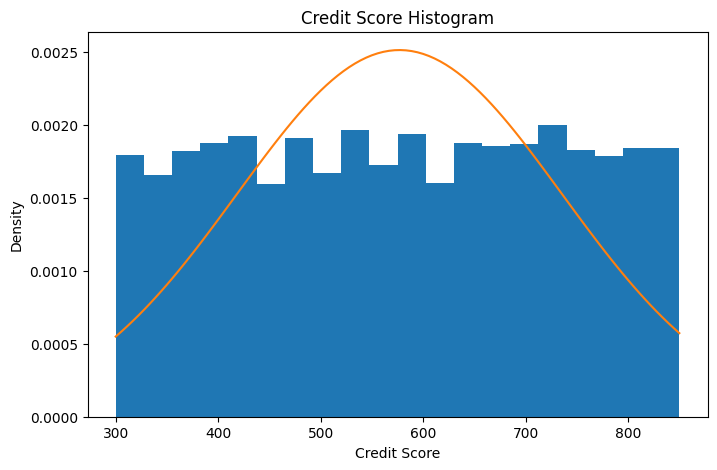

In [39]:
plt.figure(figsize=(8,5))

data = df['credit_score']

plt.hist(
    data,
    bins=20,
    density=True
)

mu = data.mean()

sigma = data.std()

x = np.linspace(
    data.min(),
    data.max(),
    100
)

plt.plot(
    x,
    stats.norm.pdf(
        x,
        mu,
        sigma
    )
)

plt.title(
    "Credit Score Histogram"
)

plt.xlabel(
    "Credit Score"
)

plt.ylabel(
    "Density"
)

plt.show()

In [40]:
skewness = stats.skew(
    df['loan_amount']
)

kurtosis = stats.kurtosis(
    df['loan_amount']
)

print(
    "Skewness :",
    skewness
)

print(
    "Kurtosis :",
    kurtosis
)

Skewness : 0.01166360827271717
Kurtosis : -1.1860788759710579


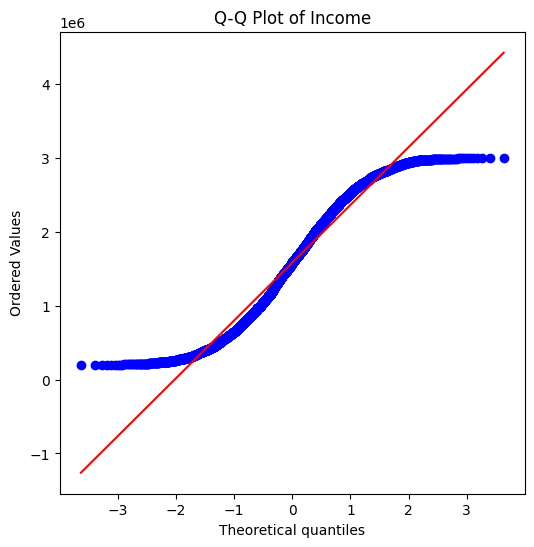

In [41]:
plt.figure(figsize=(6,6))

stats.probplot(
    df['annual_income'],
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot of Income"
)

plt.show()

In [42]:
vectors = df[
    [
        'annual_income',
        'loan_amount'
    ]
].head(5).values

print(vectors)

[[ 754030 1545379]
 [ 294857 1295809]
 [1956468  374940]
 [2112441 1880364]
 [2363322  135523]]


In [43]:
dot_product = np.dot(
    vectors[0],
    vectors[1]
)

print(
    "Dot Product :",
    dot_product
)

Dot Product : 2224847040321


In [44]:
norm1 = np.linalg.norm(
    vectors[0]
)

print(
    "Norm :",
    norm1
)

Norm : 1719522.4611911878


In [45]:
cos_theta = (
    np.dot(
        vectors[0],
        vectors[1]
    )
    /
    (
        np.linalg.norm(
            vectors[0]
        )
        *
        np.linalg.norm(
            vectors[1]
        )
    )
)

angle = np.degrees(
    np.arccos(
        cos_theta
    )
)

print(
    "Angle :",
    angle
)

Angle : 13.189744566911699
